In [43]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [44]:
# -------------------------------
# Scikit-Learn (Machine Learning utilities)
# -------------------------------
from sklearn.model_selection import train_test_split
#  Splits the dataset into training and testing sets to evaluate model performance.

from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder: Converts categorical labels (e.g., "cat", "dog") into numeric values.
# StandardScaler: Normalizes/standardizes numerical features so they have mean=0 and variance=1.

from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network). Good for binary classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score: Measures how many predictions are correct.
# classification_report: Shows precision, recall, and F1-score for each class.
# confusion_matrix: Shows where the model is making correct vs wrong predictions.

# -------------------------------
# TensorFlow / Keras (Deep Learning utilities)
# -------------------------------
import tensorflow as tf

from tensorflow.keras.models import Sequential
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).

from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.

from tensorflow.keras.utils import to_categorical
# 👉 Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0]).

In [45]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
df['Species'] = pd.Series(iris.target).map({0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'})

df.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [46]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


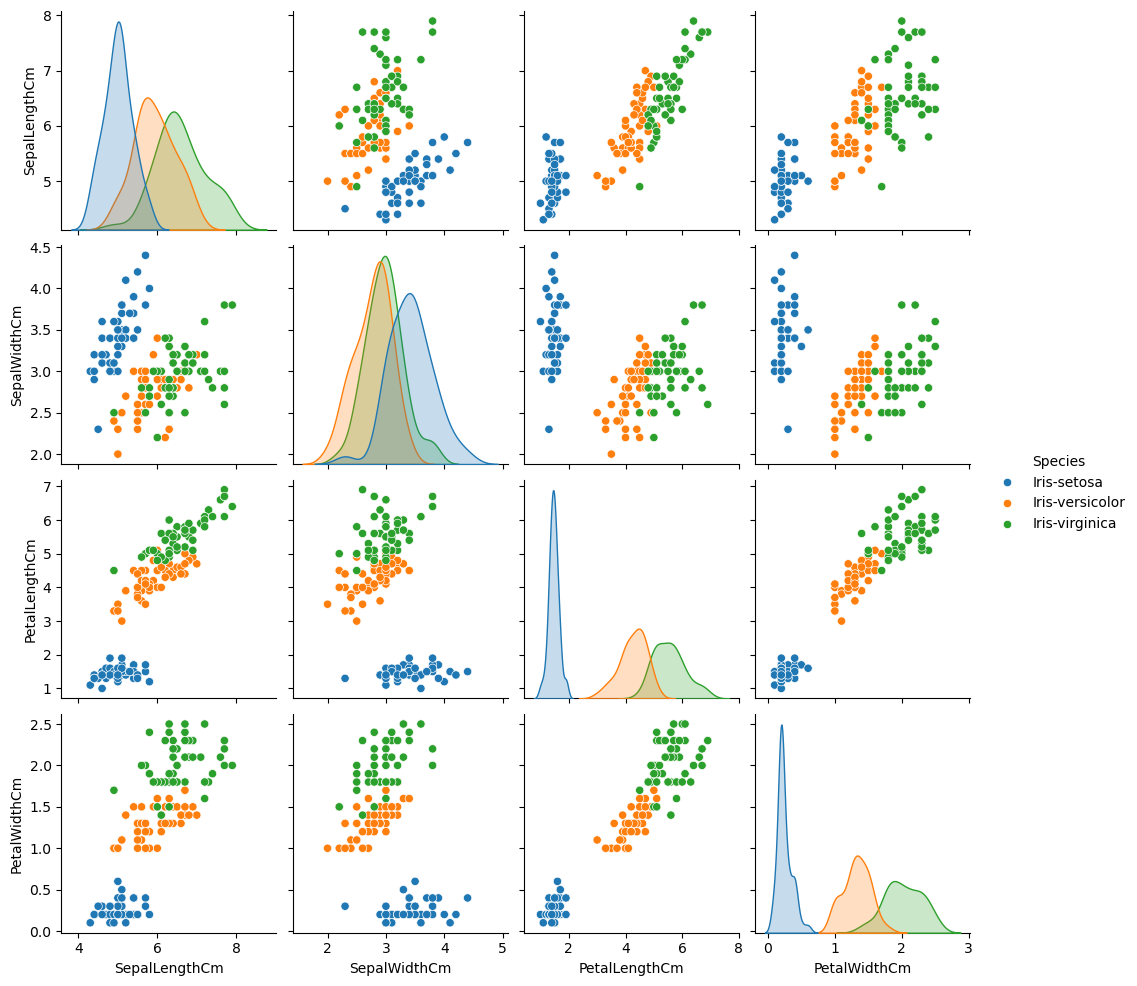

In [48]:
sns.pairplot(df,hue='Species')

In [49]:
X = df.drop(columns= ['Species'],axis = 1 )
y = df['Species']
     

In [50]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)

In [51]:
y_int

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_int, test_size=0.2, random_state=42,stratify=y_int)

In [53]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [54]:
per=Perceptron(max_iter=1000,random_state=42)
per.fit(X_train_scaled,y_train)

Perceptron(random_state=42)

In [55]:
y_Pred_per=per.predict(X_test_scaled)

In [56]:
accuracy_score(y_test,y_Pred_per)

0.9

In [57]:
print(classification_report(y_test,y_Pred_per))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.70      0.82        10
           2       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



In [58]:
y_train_cat=to_categorical(y_train,num_classes=3)
y_test_cat = to_categorical(y_test,num_classes = 3)

In [59]:
y_train_cat

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0

In [60]:
model=Sequential([
    Dense(16,input_dim=4,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])

In [61]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [62]:
history = model.fit(X_train_scaled,y_train_cat,
                epochs=100,batch_size=8,validation_split=0.2,verbose=1)

Epoch 1/100


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.2500 - loss: 1.0580 - val_accuracy: 0.4167 - val_loss: 1.0345
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 1.0188 - val_accuracy: 0.5417 - val_loss: 1.0041
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6562 - loss: 0.9862 - val_accuracy: 0.6250 - val_loss: 0.9746
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7708 - loss: 0.9518 - val_accuracy: 0.7083 - val_loss: 0.9447
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7917 - loss: 0.9168 - val_accuracy: 0.7500 - val_loss: 0.9130
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8125 - loss: 0.8787 - val_accuracy: 0.7500 - val_loss: 0.8788
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8333 - loss: 0.8375 - val_accuracy: 0.7500 - val_loss: 0.8421
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8333 - loss: 0.7956 - val_accuracy: 0.7083 - val_l

In [63]:
loss, acc=model.evaluate(X_test_scaled,y_test_cat,verbose=0)
print(acc)

0.9666666388511658


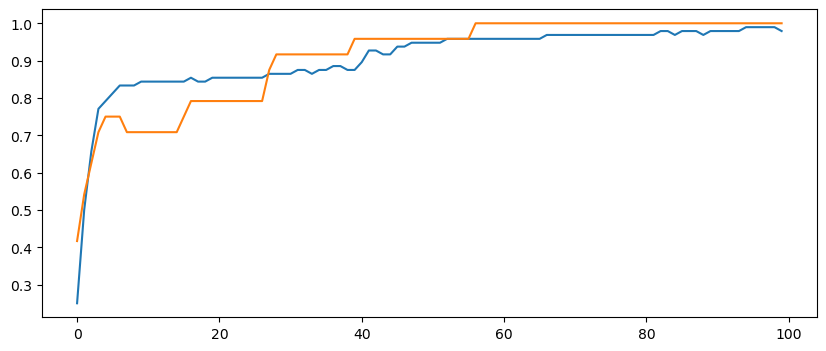

In [64]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'],label="train acc")
plt.plot(history.history['val_accuracy'],label = "val Acc")